## IADATA708  Algorithmic Fairness, Interpretability and Robustness

## German Credit (UCI) Dataset


# 1. Introduction et protocole

## Dataset

Pour ce mini-projet, nous utiliserons le **German Credit dataset**, contenant 1 000 demandes de crédit décrites par 20 variables.

Chaque demandeur est étiqueté comme bon (1) ou mauvais (2) payeur.

## Tâche

Classification binaire : prédire si un demandeur est un "mauvais risque crédit".

## Variable cible

- `y_bad = 1` → mauvais risque crédit (30 % des cas)
- `y_bad = 0` → bon risque crédit (70 % des cas)

Puisque le dataset est déséquilibré (70/30), on utilisera la **balanced accuracy** et l'**AUC-ROC** comme métriques de performance principales.

## Attribut sensible

`age_group` : `young` si âge < 25 ans, `older` si âge ≥ 25 ans.  

Cette variable sert uniquement à l'audit de fairness, elle n'est pas utilisée comme feature d'entrée du modèle.

## Coût métier

Dans ce problème, les deux types d'erreurs n'ont pas le même impact.

| Prédiction | Réalité | Coût |
|---|---|---|
| approuver le crédit | mauvais crédit | 5 |
| refuser le crédit | bon crédit | 1 |

Approuver un mauvais crédit est donc considéré comme plus coûteux que refuser un bon crédit.  
On utilise cette matrice de coût pour choisir le seuil de décision du modèle.

## Convention fairness

Le modèle prédit un score de risque :

`P(y_bad = 1)`

- Si ce score est au-dessus du seuil, le modèle prédit un mauvais risque et le crédit est refusé

- Si ce score est sous le seuil, le crédit est accordé :

`approve = 1`

Pour l'audit de fairness, l'issue favorable est donc `approve = 1`, car elle correspond à l'accès au crédit.

Nous avons donc calculés des métriques comme le taux d'approbation ou le disparate impact à partir de cette décision.

# 2. Chargement et préparation des données

Dans cette section, on charge le fichier brut du German Credit dataset, puis on prépare les variables nécessaires pour l'entraînement et l'évaluation.

Le fichier ne contient pas d'en-tête, donc on attribue manuellement les noms de colonnes à partir de la documentation du dataset.
  
On garde aussi la cible brute `raw_target`, puis on crée une cible plus pratique pour le modèle : `y_bad`.


## 2.1 Imports et constantes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seed fixe pour rendre le split / entraînement reproductibles
SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option('display.precision', 3)

# Coût métier, pour rappel : 
# prédire "bon client" alors qu'il est mauvais : coûte 5
# prédire "mauvais client" alors qu'il est bon  : coûte 1
COST_FN = 5
COST_FP = 1

# Seuil de l'attribut sensible ( young : age < 25 / older : age >= 25)
AGE_THRESHOLD = 25  

## 2.2 Chargement des données et noms des colonnes

Le dataset contient 20 variables explicatives et une variable cible. 
 
Certaines variables sont numériques (durée du prêt etc.) et d'autres sont catégorielles (type de logement etc.)

Le fichier raw est séparé par des espaces et n'a pas d'en-tête. Les noms des colonnes viennent de la documentation du dataset (`german.pdf`).

In [ ]:
COLUMNS = [
    'checking_status',            # 1  solde du compte courant
    'duration_in_month',          # 2  durée du crédit (mois)
    'credit_history',             # 3  historique de crédit
    'purpose',                    # 4  objet du crédit
    'credit_amount',              # 5  montant du crédit (DM)
    'savings_account_bonds',      # 6  épargne ou obligations
    'present_employment_since',   # 7  ancienneté de l'employé
    'installment_rate',           # 8  taux de remboursement
    'personal_status_sex',        # 9  statut civil + sexe (exclue des features)
    'other_debtors_guarantors',   # 10 autres débiteurs ou garants
    'present_residence_since',    # 11 années à l'adresse actuelle
    'property',                   # 12 bien le plus précieux possédé
    'age_in_years',               # 13 âge  (sensible donc exclue)
    'other_installment_plans',    # 14 autres plans de remboursement
    'housing',                    # 15 type de logement
    'number_of_existing_credits', # 16 nombre de crédits en cours
    'job',                        # 17 catégorie professionnelle
    'number_of_people_liable',    # 18 personnes financièrement à charge
    'telephone',                  # 19 possède un téléphone
    'foreign_worker',             # 20 travailleur étranger
    'raw_target',                 # cible => 1 = bon, 2 = mauvais
]

assert len(COLUMNS) == 21

DATA_PATH = 'data/raw/german.data'
df = pd.read_csv(DATA_PATH, sep=r'\s+', header=None, names=COLUMNS)

In [119]:
print(f'Shape : {df.shape}')
print('\nDistribution de raw_target :')
target_counts = df['raw_target'].map({1: 'bon', 2: 'mauvais'}).value_counts()
print(target_counts)
df.head()

Shape : (1000, 23)

Distribution de raw_target :
raw_target
bon        700
mauvais    300
Name: count, dtype: int64


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,y_bad,age_group
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A143,A152,2,A173,1,A192,A201,1,0,older
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A143,A152,1,A173,1,A191,A201,2,1,young
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A143,A152,1,A172,2,A191,A201,1,0,older
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A143,A153,1,A173,2,A191,A201,1,0,older
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A143,A153,2,A173,2,A191,A201,2,1,older


## 2.3 Variable cible et attribut sensible

La cible brute du dataset vaut 1 pour un bon crédit et 2 pour un mauvais crédit.  
Pour entraîner le modèle, nous la transformons en variable binaire plus simple :

- `y_bad = 1` : mauvais risque crédit ;
- `y_bad = 0` : bon risque crédit.

On crée aussi l'attribut sensible `age_group` à partir de `age_in_years`.  
On utilise deux groupes : `young` si l'âge est inférieur à 25 ans, et `older` sinon.

La variable `personal_status_sex` est aussi exclue, car elle mélange sexe et statut marital ->ce qui rend son interprétation plus "compliqué"


In [121]:
df['y_bad'] = (df['raw_target'] == 2).astype(int)
print(f"y_bad = 1 (mauvais) : {df['y_bad'].sum()}  ({df['y_bad'].mean():.1%})")
print(f"y_bad = 0 (bon)     : {(1 - df['y_bad']).sum()}  ({1 - df['y_bad'].mean():.1%})")

y_bad = 1 (mauvais) : 300  (30.0%)
y_bad = 0 (bon)     : 700  (70.0%)


In [123]:
df['age_group'] = np.where(df['age_in_years'] < AGE_THRESHOLD, 'young', 'older')
print(df['age_group'].value_counts().to_string())
print('\nDéfaut par groupe :')
print(df.groupby('age_group')['y_bad'].mean().rename('taux y_bad').round(3))

age_group
older    851
young    149

Défaut par groupe :
age_group
older    0.281
young    0.409
Name: taux y_bad, dtype: float64


## 2.4 Listes de variables

On sépare les variables numériques et catégorielles car elles ne seront pas prétraitées de la même façon.  
`FEATURE_COLS` contient uniquement les variables que le modèle pourra utiliser.

In [124]:
# Var numériques
NUMERIC_COLS_ALL = [
    'duration_in_month',
    'credit_amount',
    'installment_rate',
    'present_residence_since',
    'age_in_years',
    'number_of_existing_credits',
    'number_of_people_liable',
]

# Var catégorielles
CATEG_COLS_ALL = [
    'checking_status',
    'credit_history',
    'purpose',
    'savings_account_bonds',
    'present_employment_since',
    'personal_status_sex',
    'other_debtors_guarantors',
    'property',
    'other_installment_plans',
    'housing',
    'job',
    'telephone',
    'foreign_worker',
]

# Exclues (sensible ou ambigue)
SENSITIVE_COLS = ['age_in_years', 'personal_status_sex']

FEATURE_COLS = [c for c in NUMERIC_COLS_ALL + CATEG_COLS_ALL if c not in SENSITIVE_COLS]

# On vérifie que les vars sensibles ne sont pas utilisés par le modèle
assert 'age_in_years' not in FEATURE_COLS
assert 'personal_status_sex' not in FEATURE_COLS
assert len(NUMERIC_COLS_ALL) + len(CATEG_COLS_ALL) == 20  

In [126]:
n_num  = sum(c in NUMERIC_COLS_ALL for c in FEATURE_COLS)
n_cat  = sum(c in CATEG_COLS_ALL  for c in FEATURE_COLS)
print(f'Variables numériques  dans FEATURE_COLS : {n_num}')
print(f'Variables catégorielles dans FEATURE_COLS : {n_cat}')
print(f'Total features : {len(FEATURE_COLS)}')

Variables numériques  dans FEATURE_COLS : 6
Variables catégorielles dans FEATURE_COLS : 12
Total features : 18


## 2.5 Découpage train / validation / test

On coupe le jeu de données en trois parties : 
- **train (60 %)**
- **validation (20 %)**
- **test (20 %)**  

Le découpage est stratifié sur `y_bad` pour conserver le ratio 70/30 dans chaque split.

In [127]:
# Fonction de split
def stratified_split(y, ratios, seed=SEED):
    y = np.asarray(y)
    rng_split = np.random.default_rng(seed)

    splits = [[] for _ in ratios]

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng_split.shuffle(idx)

        n_train = int(round(ratios[0] * len(idx)))
        n_val = int(round(ratios[1] * len(idx)))

        splits[0].extend(idx[:n_train])
        splits[1].extend(idx[n_train:n_train + n_val])
        splits[2].extend(idx[n_train + n_val:])

    final_splits = []
    for split in splits:
        split = np.array(split)
        rng_split.shuffle(split)
        final_splits.append(split)

    return final_splits

In [128]:
# Application
idx_train, idx_val, idx_test = stratified_split(df['y_bad'].values,ratios=[0.6, 0.2, 0.2])

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val = df.iloc[idx_val].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

print(f"Train : {len(df_train)} lignes")
print(f"Val   : {len(df_val)} lignes")
print(f"Test  : {len(df_test)} lignes")

Train : 600 lignes
Val   : 200 lignes
Test  : 200 lignes


## 2.6 Vérification du découpage

Le split étant fait, on vérifie 2 choses:

- chaque partie garde environ 30% de mauvais crédits
- les 2 groupes d'âge sont présents dans train / validation / test.

C'est obligatoire car le modèle doit être entrainé sur un split représentatif.

In [129]:
rows = []
for name, split in [('train', df_train),('val', df_val),('test', df_test)]:
    rows.append({
        'split'      : name,
        'n'          : len(split),
        'bad_rate'   : split['y_bad'].mean(),
        'young_rate' : (split['age_group'] == 'young').mean(),
        'older_rate' : (split['age_group'] == 'older').mean(),
    })

split_summary = pd.DataFrame(rows).set_index('split')
split_summary

,n,bad_rate,young_rate,older_rate
split,,,,
train,600,0.3,0.155,0.845
val,200,0.3,0.145,0.855
test,200,0.3,0.135,0.865


Les trois splits gardent bien un taux de mauvais crédits de 30 % (bad_rate à 0.3).  

Les deux groupes d'âge sont aussi présents dans chaque split donc on pourra comparer les décisions du modèle entre groupes.

# 3. Modèle baseline

## 3.1 Preprocessor

Avant d'entraîner le modèle, les données doivent être transformées en matrice numérique.

La régression logistique ne peut pas utiliser directement des catégories comme `A11` ou `A34`.  
-> On utilise donc un one-hot encoding, chaque modalité devient une colonne binaire.

Les variables numériques ont aussi des échelles différentes (exemple :`credit_amount` peut être beaucoup plus grand que `installment_rate`).  
On les standardise avec un z-score en utilisant la moyenne et l'écart-type calculés sur le train.

On crée une classe `Preprocessor` pour faire cette préparation toujours de la même façon :
- On utilise la moyenne et l'écart type du train pour standardisées les vars numériques
- on encode les vars catégorielles en one-hot
- les mêmes colonnes sont gardées pour train / validation / test.

Le `Preprocessor` est ajusté uniquement sur le train, ce qui évite d'utiliser des informations venant de la validation ou du test.

La liste `feature_names_` garde le nom des colonnes après encodage.

In [130]:
class Preprocessor:
    def fit(self, df):
        self.num_cols_ = [c for c in FEATURE_COLS if c in NUMERIC_COLS_ALL]
        self.cat_cols_ = [c for c in FEATURE_COLS if c in CATEG_COLS_ALL]

        self.means_ = df[self.num_cols_].mean().values
        self.stds_ = df[self.num_cols_].std(ddof=0).values
        self.stds_[self.stds_ == 0] = 1 

        self.categories_ = {col: sorted(df[col].unique()) for col in self.cat_cols_}

        self.feature_names_ = list(self.num_cols_)
        for col, cats in self.categories_.items():
            self.feature_names_ += [f"{col}__{cat}" for cat in cats]

        return self

    def transform(self, df):
        parts = []

        # z-score pour vals numériques
        num = (df[self.num_cols_].values - self.means_) / self.stds_
        parts.append(num)

        # one-hot pour catégorielles
        for col, cats in self.categories_.items():
            ohe = np.column_stack([(df[col] == cat).astype(float).values for cat in cats])
            parts.append(ohe)

        return np.hstack(parts)

On n'utilise pas `get_dummies` (pd.get_dummies) sur tout le dataset avant le split, car cela ferait dépendre le preprocessing du test.

## 3.2 Fit + transform

On ajuste le `Preprocessor` uniquement sur le train, puis on l'applique à la validation et au test.  
Ca évite toute fuite d'information depuis les données d'évaluation.

On va aussi récuperer :
- `X_*` : les variables d'entrée encodées 
- `y_*` : la cible à prédire 
- `s_*` : le groupe sensible 

In [131]:
prep = Preprocessor().fit(df_train)

# Matrices de features
X_train = prep.transform(df_train)
X_val   = prep.transform(df_val)
X_test  = prep.transform(df_test)

# Cibles
y_train = df_train['y_bad'].values
y_val   = df_val  ['y_bad'].values
y_test  = df_test ['y_bad'].values

# Attribut sensible
s_train = df_train['age_group'].values
s_val   = df_val  ['age_group'].values
s_test  = df_test ['age_group'].values

assert 'age_in_years'       not in prep.feature_names_
assert 'personal_status_sex' not in prep.feature_names_

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}")
print(f"Nombre de features (après one-hot) : {X_train.shape[1]}")

X_train : (600, 56)  |  X_val : (200, 56)  |  X_test : (200, 56)
Nombre de features (après one-hot) : 56


## 3.3 Entraînement de la régression logistique

On utilise une régression logistique binaire comme modèle baseline car c'est un modèle simple et adapté aux données tabulaires.

Le modèle prédit un score entre 0 et 1 avec la fonction sigmoid.  
Ce score représente `P(y_bad = 1)`, donc la probabilité que le demandeur soit un mauvais risque crédit.

Pour une classification binaire, la loss classique est **la binary cross-entropy**, ce que notre entrainement minimise.

Au lieu d'une GD simple, on utilise l'optimiseur **ADAM**.
-> ADAM adapte automatiquement la taille des MAJ pour chaque paramètre, cela nous évité de dépendre d'un choix du "parfait" du learning rate.

La fonction accepte aussi `sample_weight`:  
Ca servira plus tard pour le reweighing car certains exemples auront plus ou moins d'importance pendant l'entraînement.

On ajoute aussi une **régularisation L2** sur les poids `w` pour réduire le risque d'overfitting et limiter les coeffs trop grands.


In [132]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def train_logreg(X, y, lr=0.01, epochs=2000, l2=1e-4, sample_weight=None, seed=SEED):
    rng_w = np.random.default_rng(seed)
    n, p  = X.shape

    w = rng_w.normal(0, 0.01, p)
    b = 0.0

    # Poids des exemples pour reweighing
    sw = np.ones(n) if sample_weight is None else np.asarray(sample_weight, float)
    sw = sw / sw.sum()  

    # Hyper-param ADAM
    beta1, beta2, eps_adam = 0.9, 0.999, 1e-8
    mw, vw = np.zeros(p), np.zeros(p)
    mb, vb = 0.0, 0.0

    losses = []

    for t in range(1, epochs + 1):
        y_hat = sigmoid(X @ w + b)
        err   = sw * (y_hat - y)       

        gw = X.T @ err + l2 * w
        gb = err.sum()

        ce = -sw * (y * np.log(y_hat + 1e-12) + (1 - y) * np.log(1 - y_hat + 1e-12))
        losses.append(ce.sum() + 0.5 * l2 * (w @ w))

        mw = beta1 * mw + (1 - beta1) * gw
        vw = beta2 * vw + (1 - beta2) * gw ** 2
        w -= lr * (mw / (1 - beta1**t)) / (np.sqrt(vw / (1 - beta2**t)) + eps_adam)

        mb = beta1 * mb + (1 - beta1) * gb
        vb = beta2 * vb + (1 - beta2) * gb ** 2
        b -= lr * (mb / (1 - beta1**t)) / (np.sqrt(vb / (1 - beta2**t)) + eps_adam)

    return w, b, losses

In [133]:
# Entrainement du modèle baseline
w_base, b_base, losses_base = train_logreg(X_train, y_train)
print(f"Loss initiale : {losses_base[0]:.4f}  |  Loss finale : {losses_base[-1]:.4f}")

Loss initiale : 0.6932  |  Loss finale : 0.4521


## 3.4 Sélection du seuil

### 3.4.1 Fonctions utiles pour évaluer un seuil

Avant de choisir le seuil, on définit quelques fonctions simples pour calculer la matrice de confusion, la balanced accuracy et le coût métier.

In [ ]:
# Fonctions utilaires
def confusion_counts(y, pred):
    tp = int(np.sum((pred == 1) & (y == 1)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))
    return tp, fp, tn, fn

def balanced_accuracy_from_counts(tp, fp, tn, fn):
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return (tpr + tnr) / 2

def business_cost_from_counts(tp, fp, tn, fn):
    return COST_FN * fn + COST_FP * fp

def evaluate_thresholds(y, scores, thresholds):
    rows = []

    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        tp, fp, tn, fn = confusion_counts(y, pred)

        rows.append({
            'threshold': thr,
            'business_cost': business_cost_from_counts(tp, fp, tn, fn),
            'balanced_accuracy': balanced_accuracy_from_counts(tp, fp, tn, fn),
        })

    return pd.DataFrame(rows)


### 3.4.2 Choix du seuil sur validation

Le modèle donne un score de risque `P(y_bad = 1)`.  
-> Il faut choisir un seuil pour transformer ce score en décision.

On teste plusieurs seuils entre 0.01 et 0.99 sur validation set.  
On compare deux choix :

- `thr_cost` : seuil qui minimise le coût métier 
- `thr_balacc` : seuil qui maximise la balanced accuracy

On garde `thr_cost` comme seuil principal, car les erreurs n'ont pas le même coût dans notre cas.

In [136]:
scores_val = sigmoid(X_val @ w_base + b_base)
thresholds = np.linspace(0.01, 0.99, 99)

threshold_results = evaluate_thresholds(y_val, scores_val, thresholds)

idx_cost = threshold_results['business_cost'].idxmin()
idx_balacc = threshold_results['balanced_accuracy'].idxmax()

thr_cost = threshold_results.loc[idx_cost, 'threshold']
thr_balacc = threshold_results.loc[idx_balacc, 'threshold']

thr_base = thr_cost

threshold_summary = pd.DataFrame([
    {
        'seuil': 'thr_cost',
        'valeur': round(float(thr_cost), 2),
        'coût métier': int(threshold_results.loc[idx_cost, 'business_cost']),
        'balanced acc.': round(float(threshold_results.loc[idx_cost, 'balanced_accuracy']), 3),
    },
    {
        'seuil': 'thr_balacc',
        'valeur': round(float(thr_balacc), 2),
        'coût métier': int(threshold_results.loc[idx_balacc, 'business_cost']),
        'balanced acc.': round(float(threshold_results.loc[idx_balacc, 'balanced_accuracy']), 3),
    },
]).set_index('seuil')

threshold_summary

,valeur,coût métier,balanced acc.
seuil,,,
thr_cost,0.15,100,0.719
thr_balacc,0.26,115,0.732


Le seuil `thr_cost` est plus "prudent", il cherche surtout à limiter les mauvais crédits approuvés.  
C'est cohérent avec la matrice de coût du dataset où ce type d'erreur coûte plus cher.

# 4. Évaluation du baseline

## 4.1 Fonctions métriques

On regroupe ici les fonctions qui serviront à évaluer le modèle.

Plusieurs métriques sont intéressantes à garder :
- `accuracy` : proportion totale de bonnes prédictions 
- `balanced_accuracy` : moyenne entre la détection des mauvais crédits et celle des bons crédits 
- `AUC-ROC` : qualité du score de risque (indépendamment du seuil choisi) 
- `business_cost` : coût métier (basé sur la matrice de coût)

On calcule l'AUC sans sklearn, elle mesure si les mauvais crédits reçoivent en général un score de risque plus élevé que les bons crédits.

In [137]:
def accuracy_from_counts(tp, fp, tn, fn):
    return (tp + tn) / (tp + fp + tn + fn)


def roc_auc_score_manual(y, scores):
    y      = np.asarray(y)
    scores = np.asarray(scores)
    pos    = scores[y == 1]
    neg    = scores[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    count  = np.sum(pos[:, None] > neg) + 0.5 * np.sum(pos[:, None] == neg)
    return float(count / (len(pos) * len(neg)))


def predict_from_scores(scores, threshold):
    return (scores >= threshold).astype(int)


def approve_from_pred(risk_pred):
    return 1 - risk_pred


def evaluate_predictions(y, scores, threshold):
    pred = predict_from_scores(scores, threshold)
    tp, fp, tn, fn = confusion_counts(y, pred)
    return {
        'accuracy'         : accuracy_from_counts(tp, fp, tn, fn),
        'balanced_accuracy': balanced_accuracy_from_counts(tp, fp, tn, fn),
        'roc_auc'          : roc_auc_score_manual(y, scores),
        'business_cost'    : business_cost_from_counts(tp, fp, tn, fn),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    }

## 4.2 Évaluation du baseline sur le test

On évalue le modèle baseline sur le test set.

Le seuil `thr_base` a été choisi avant mais seulement pour le validation set.  
Notre test sert donc seulement à mesurer la performance finale du modèle.

On calcule aussi `approve_test`, car cette décision sera utilisée ensuite pour l'audit de fairness.

In [138]:
scores_test      = sigmoid(X_test @ w_base + b_base)
risk_pred_test   = predict_from_scores(scores_test, thr_base)
approve_test     = approve_from_pred(risk_pred_test)

metrics_base = evaluate_predictions(y_test, scores_test, thr_base)

baseline_summary = {
    'threshold'        : round(float(thr_base), 2),
    'accuracy'         : round(metrics_base['accuracy'],          3),
    'balanced_accuracy': round(metrics_base['balanced_accuracy'], 3),
    'roc_auc'          : round(metrics_base['roc_auc'],           3),
    'business_cost'    : metrics_base['business_cost'],
    'TP'               : metrics_base['TP'],
    'FP'               : metrics_base['FP'],
    'TN'               : metrics_base['TN'],
    'FN'               : metrics_base['FN'],
    'approval_rate'    : round(approve_test.mean(), 3),
}

pd.DataFrame([baseline_summary]).set_index('threshold')

,accuracy,balanced_accuracy,roc_auc,business_cost,TP,FP,TN,FN,approval_rate
threshold,,,,,,,,,
0.15,0.66,0.719,0.789,100,52,60,80,8,0.44


Le modèle obtient une AUC correcte, ce qui indique que le score de risque classe assez bien les bons et mauvais crédits.

Le seuil choisi cherche à limiter les faux négatifs, c-à-d les mauvais crédits approuvés.  

Cela peut augmenter le nombre de bons clients refusés mais c'est cohérent avec le coût métier.

## 4.3 Matrice de confusion

La matrice de confusion permet de voir plus concrètement les erreurs du modèle sur le test set.

Les lignes correspondent à la vraie classe, et les colonnes à la classe prédite.

On peut distinguer :
- les bonnes prédictions ;
- les faux positifs : bons clients refusés ;
- les faux négatifs : mauvais crédits approuvés.

Dans notre cas,c'est surtout les faux négatifs qui noous interessent car ce sont les erreurs les plus coûteuses dans la matrice de coût métier.

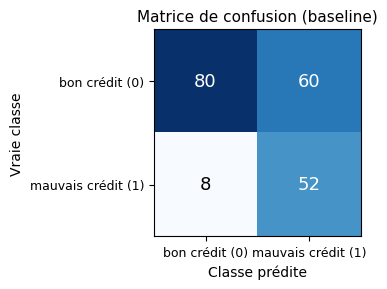

In [139]:
tp = metrics_base['TP']
fp = metrics_base['FP']
tn = metrics_base['TN']
fn = metrics_base['FN']

cm = np.array([[tn, fp], [fn, tp]])

labels = ['bon crédit (0)', 'mauvais crédit (1)']

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Classe prédite',  fontsize=10)
ax.set_ylabel('Vraie classe',    fontsize=10)
ax.set_title('Matrice de confusion (baseline)', fontsize=11)

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=13, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

Les faux négatifs correspondent aux cas où un mauvais crédit est prédit comme bon.  
Ce sont les erreurs les plus graves ici, car elles coûtent 5 fois plus qu’un faux positif.

Les faux positifs correspondent à des bons clients refusés à tort.  
Ils sont moins coûteux mais réduisent le taux d’approbation global.

## 4.4 Courbe ROC

La courbe ROC montre le compromis entre :
- le taux de mauvais crédits correctement détectés (TPR)
- le taux de bons clients refusés à tort (FPR)

Elle permet d’évaluer la qualité du score de risque sans dépendre d’un seuil précis.  
-> Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.

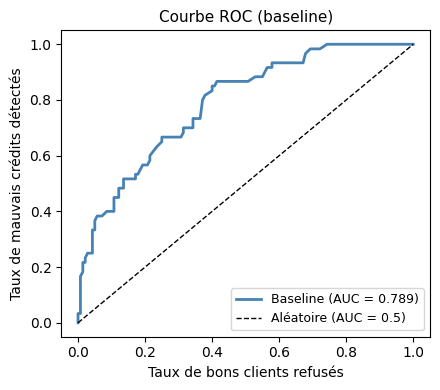

In [140]:
auc = roc_auc_score_manual(y_test, scores_test)

tprs, fprs = [], []
for thr in np.linspace(1, 0, 200): 
    pred = predict_from_scores(scores_test, thr)
    tp, fp, tn, fn = confusion_counts(y_test, pred)
    tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(fprs, tprs, color='steelblue', lw=2, label=f'Baseline (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de bons clients refusés', fontsize=10)
ax.set_ylabel('Taux de mauvais crédits détectés', fontsize=10)
ax.set_title('Courbe ROC (baseline)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

L’AUC résume la qualité globale du score de risque :

- un modèle aléatoire obtient une AUC de 0.5 ;
- un modèle parfait obtient une AUC de 1.


# 5. Audit de fairness

## 5.1 Fonction d'audit fairness

Pour l'audit de fairness, on se place plutôt du point de vue du demandeur.  
L'issue favorable est donc `approve = 1`, c'est-à-dire obtenir le crédit.

On calcule d'abord des métriques par groupe d'âge :
- `approval_rate` : proportion de crédits accordés 
- `tpr_risk` : proportion de mauvais crédits correctement détectés 
- `fpr_risk` : proportion de bons crédits refusés à tort 
- `tnr_risk` : proportion de bons crédits correctement acceptés

Ensuite, on calcule plusieurs métriques globales de fairness :
- `dp_diff` : écart de taux d'approbation entre groupes 
- `disparate_impact` : ratio des taux d'approbation 
- `eo_diff` : écart de taux d'approbation parmi les vrais bons clients 
- `eodds_gap` : plus grand écart entre TPR et FPR.

In [ ]:
def fairness_audit(y, approve, sens):
    y       = np.asarray(y,       int)
    approve = np.asarray(approve, int)
    sens    = np.asarray(sens)
    risk    = 1 - approve 

    def _safe_diff(a, b):
        return abs(a - b) if not (np.isnan(a) or np.isnan(b)) else np.nan

    rows = {}
    for grp in ['young', 'older']:
        m      = sens == grp
        y_g    = y[m]
        app_g  = approve[m]
        risk_g = risk[m]

        pos = y_g == 1  
        neg = y_g == 0  

        fpr = float(risk_g[neg].mean()) if neg.sum() > 0 else np.nan
        rows[grp] = {
            'n'            : int(m.sum()),
            'bad_rate'     : float(y_g.mean()),
            'approval_rate': float(app_g.mean()),
            'tpr_risk'     : float(risk_g[pos].mean()) if pos.sum() > 0 else np.nan,
            'fpr_risk'     : fpr,
            'tnr_risk'     : (1 - fpr) if not np.isnan(fpr) else np.nan,
        }

    ar  = {g: rows[g]['approval_rate'] for g in ('young', 'older')}
    tpr = {g: rows[g]['tpr_risk']      for g in ('young', 'older')}
    fpr = {g: rows[g]['fpr_risk']      for g in ('young', 'older')}
    tnr = {g: rows[g]['tnr_risk']      for g in ('young', 'older')}

    summary = {
        'dp_diff'         : _safe_diff(ar['young'], ar['older']),
        'disparate_impact': (
            ar['young'] / ar['older']
            if not np.isnan(ar['older']) and ar['older'] > 0
            else np.nan
        ),
        'eo_diff'         : _safe_diff(tnr['young'], tnr['older']),
        'eodds_gap'       : max(_safe_diff(tpr['young'], tpr['older']),
                                _safe_diff(fpr['young'], fpr['older'])),
    }

    return pd.DataFrame(rows).T, summary

## 5.2 Audit fairness -> baseline

On applique maintenant l'audit de fairness au baseline sur le test set.

On utilise `approve_test`, car les métriques de fairness doivent être calculées sur la décision finale : crédit accordé ou refusé.

In [144]:
fair_base_by_group, fair_base_summary = fairness_audit(y_test, approve_test, s_test)

print("Métriques par groupe")
display(fair_base_by_group.round(3))

print("\nMétriques globales de fairness")
fair_base_summary_df = pd.DataFrame([fair_base_summary]).round(3)
display(fair_base_summary_df)

Métriques par groupe


,n,bad_rate,approval_rate,tpr_risk,fpr_risk,tnr_risk
young,27.0,0.370,0.333,0.90,0.529,0.471
older,173.0,0.289,0.457,0.86,0.415,0.585



Métriques globales de fairness


,dp_diff,disparate_impact,eo_diff,eodds_gap
0,0.123,0.73,0.115,0.115


Dans ce split, les groupes `young` et `older` n'ont pas exactement le même taux de mauvais crédits.
Ca peut expliquer une partie de l'écart d'approbation mais ne suffit pas à conclure seul.

Le `disparate_impact` compare les taux d'approbation des deux groupes : une valeur proche de 1 indique des taux similaires.

`dp_diff`, `eo_diff` et `eodds_gap` sont des écarts : plus elles sont proches de 0, plus les décisions sont similaires entre groupes selon la métrique choisie.

## 5.3 Visualisation fairness

On visualise trois métriques importantes pour comparer les groupes `young` et `older`.

- `approval_rate` mesure l'accès global au crédit 
- `tnr_risk` mesure le taux de bons clients correctement acceptés 
- `fpr_risk` mesure le taux de bons clients refusés à tort

Ces trois métriques permettent de voir si un groupe reçoit moins souvent le crédit, même parmi les vrais bons profils.

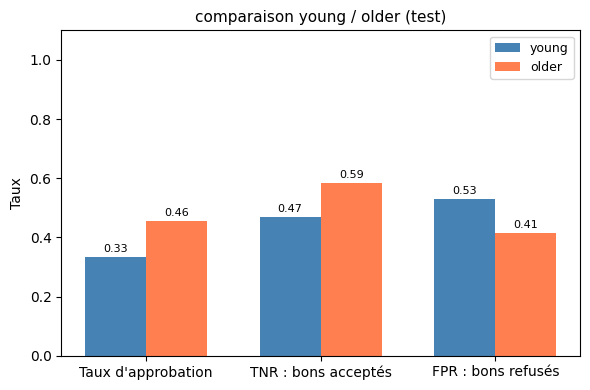

In [145]:
metrics_to_plot = ['approval_rate', 'tnr_risk', 'fpr_risk']
groups          = ['young', 'older']
colors          = ['steelblue', 'coral']

x      = np.arange(len(metrics_to_plot))
width  = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

for i, (grp, color) in enumerate(zip(groups, colors)):
    values = [float(fair_base_by_group.loc[grp, m]) for m in metrics_to_plot]
    bars   = ax.bar(x + (i - 0.5) * width, values, width, label=grp, color=color)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Taux d\'approbation', 'TNR : bons acceptés', 'FPR : bons refusés'], fontsize=10)
ax.set_ylabel('Taux', fontsize=10)
ax.set_title('comparaison young / older (test)', fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

`approval_rate` mesure l'accès direct au crédit pour chaque groupe.  
-> Indique que les deux groupes ne reçoivent pas le crédit au même taux si l'écart est important.

`tnr_risk` correspond au taux d'approbation parmi les vrais bons clients.  
-> Si ce taux est plus bas pour un groupe, cela signifie que ce groupe est plus souvent refusé même lorsque le crédit était bon.

`fpr_risk` représente les bons clients refusés à tort par le modèle.  
-> Importante car elle montre une erreur défavorable pour le demandeur.

# 6. Correction du biais (fairness mitigation)

## 6.1 Reweighing

Pour essayer de réduire les écarts entre groupes, on utilise une méthode simple de pré-traitement : le **reweighing**.

Ici, l'idée est de donner un poids différent à chaque exemple avant l'entraînement. 

On ne modifie pas les variables et on ne change pas le modèle, on change seulement l'importance de certains exemples dans la loss.

La formule est : `w_i = P(S=s_i) × P(Y=y_i) / P(S=s_i, Y=y_i)`

avec `S` le groupe sensible (`age_group`) et `Y` la classe (`y_bad`).

- Si une combinaison groupe/classe est sous-représentée, elle reçoit un poids plus élevé.  
- Si elle est sur-représentée, elle reçoit un poids plus faible.

Le but est de réduire la dépendance entre le groupe sensible et la cible pendant l'entraînement.

In [146]:
def reweighing_weights(y, sens):
    y    = np.asarray(y)
    sens = np.asarray(sens)
    n    = len(y)
    weights = np.ones(n, dtype=float)

    for grp in np.unique(sens):
        for cls in np.unique(y):
            mask = (sens == grp) & (y == cls)
            p_s  = (sens == grp).mean()   
            p_y  = (y == cls).mean()      
            p_sy = mask.mean()          
            if p_sy > 0:
                weights[mask] = p_s * p_y / p_sy
    return weights

w_train = reweighing_weights(y_train, s_train)

# petit vérification -> poids moyens par groupe × classe
rows = []
for grp in ['young', 'older']:
    for cls in [0, 1]:
        mask = (s_train == grp) & (y_train == cls)
        rows.append({
            'group'      : grp,
            'y_bad'      : cls,
            'n'          : int(mask.sum()),
            'mean_weight': round(float(w_train[mask].mean()), 4) if mask.sum() > 0 else np.nan,
        })

pd.DataFrame(rows)

,group,y_bad,n,mean_weight
0,young,0,54,1.206
1,young,1,39,0.715
2,older,0,366,0.970
3,older,1,141,1.079


## 6.2 Entraînement du modèle avec reweighing

On entraîne maintenant un second modèle avec les poids calculés précédemment.

Pour que la comparaison soit "juste", on garde exactement la même architecture que le baseline, donc :
- même régression logistique 
- mêmes features 
- même fonction d'entraînement
- même méthode de choix du seuil

La seule différence est l'utilisation de `sample_weight=w_train` pendant l'entraînement.  
Comme ca, si les résultats changent, on peut les attribuer au reweighing.

In [147]:
# Entraînement avec les poids de reweighing
w_fair, b_fair, losses_fair = train_logreg(
    X_train,
    y_train,
    sample_weight=w_train
)

print(f"Loss initiale : {losses_fair[0]:.4f}  |  Loss finale : {losses_fair[-1]:.4f}")

# Seuil de validation
scores_val_fair = sigmoid(X_val @ w_fair + b_fair)
threshold_results_fair = evaluate_thresholds(y_val, scores_val_fair, thresholds)

idx_cost_fair = threshold_results_fair['business_cost'].idxmin()
thr_fair = threshold_results_fair.loc[idx_cost_fair, 'threshold']

print(f"Seuil retenu (coût val) : {thr_fair:.2f}")

# Évaluation sur test
scores_fair_test = sigmoid(X_test @ w_fair + b_fair)
risk_pred_fair_test = predict_from_scores(scores_fair_test, thr_fair)
approve_fair_test = approve_from_pred(risk_pred_fair_test)

fair_model_metrics = evaluate_predictions(y_test, scores_fair_test, thr_fair)
fair_model_by_group, fair_model_summary = fairness_audit(
    y_test,
    approve_fair_test,
    s_test
)

print("\nMétriques test du modèle reweighing :")
display(pd.DataFrame([fair_model_metrics]).round(3))

print("Fairness par groupe :")
display(fair_model_by_group.round(3))

Loss initiale : 0.6934  |  Loss finale : 0.4534
Seuil retenu (coût val) : 0.15

Métriques test du modèle reweighing :


,accuracy,balanced_accuracy,roc_auc,business_cost,TP,FP,TN,FN
0,0.655,0.715,0.789,101,52,61,79,8


Fairness par groupe :


,n,bad_rate,approval_rate,tpr_risk,fpr_risk,tnr_risk
young,27.0,0.370,0.333,0.90,0.529,0.471
older,173.0,0.289,0.451,0.86,0.423,0.577


## 6.3 Comparaison baseline vs reweighing

On compare maintenant le modèle baseline et le modèle entraîné avec reweighing.

L'objectif n'est pas seulement de regarder la performance classique, on aussi  
comparer le coût métier et les métriques de fairness, car une méthode de mitigation peut améliorer un critère tout en en dégradant un autre.

In [148]:
def _row(name, thr, metrics, approval_rate, fairness):
    return {
        'model'            : name,
        'threshold'        : round(float(thr), 2),
        'accuracy'         : round(metrics['accuracy'],          3),
        'balanced_accuracy': round(metrics['balanced_accuracy'], 3),
        'roc_auc'          : round(metrics['roc_auc'],           3),
        'business_cost'    : metrics['business_cost'],
        'approval_rate'    : round(float(approval_rate),         3),
        'dp_diff'          : round(fairness['dp_diff'],          3),
        'disparate_impact' : round(fairness['disparate_impact'], 3),
        'eo_diff'          : round(fairness['eo_diff'],          3),
        'eodds_gap'        : round(fairness['eodds_gap'],        3),
    }

comparison = pd.DataFrame([
    _row('Baseline',   thr_base, metrics_base,       approve_test.mean(),      fair_base_summary),
    _row('Reweighing', thr_fair, fair_model_metrics, approve_fair_test.mean(), fair_model_summary),
]).set_index('model')

display(comparison)

,threshold,accuracy,balanced_accuracy,roc_auc,business_cost,approval_rate,dp_diff,disparate_impact,eo_diff,eodds_gap
model,,,,,,,,,,
Baseline,0.15,0.660,0.719,0.789,100,0.440,0.123,0.730,0.115,0.115
Reweighing,0.15,0.655,0.715,0.789,101,0.435,0.118,0.739,0.107,0.107


Dans ce test, le reweighing modifie légèrement les résultats par rapport au baseline.

Certaines métriques de fairness peuvent s'améliorer, comme `dp_diff` ou `eo_diff`, mais cette l'amélioration reste limitée.  

Cependant, la performance globale et le coût métier restent proches du baseline.

Ce résultat nous montre qu'une méthode de mitigation simple ne rend pas automatiquement le modèle équitable sur toutes les métriques.  

Par la suite il faut donc analyser performance, coût métier et fairness.

# 7. Interprétabilité

## 7.1 Coefficients globaux du modèle

Comme le modèle baseline est une régression logistique, ses coefficients sont directement interprétables.

Chaque coefficient indique comment une feature influence le score de risque `P(y_bad = 1)` :
- un coefficient positif pousse le modèle vers la classe “mauvais crédit” ;
- un coefficient négatif pousse le modèle vers la classe “bon crédit”.

Ici les coefficients les plus grands en valeur absolue sont ceux qui ont le plus d'effet sur le score du modèl.

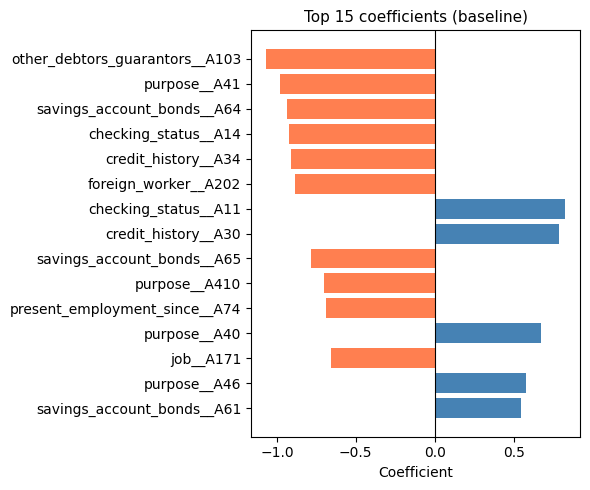

,feature,coef
0,other_debtors_guarantors__A103,-1.068
1,purpose__A41,-0.983
2,savings_account_bonds__A64,-0.937
3,checking_status__A14,-0.925
4,credit_history__A34,-0.912
5,foreign_worker__A202,-0.883
6,checking_status__A11,0.826
7,credit_history__A30,0.789
8,savings_account_bonds__A65,-0.781
9,purpose__A410,-0.700


In [150]:
coef_df = pd.DataFrame({
    'feature' : prep.feature_names_,
    'coef'    : w_base,
    'abs_coef': np.abs(w_base),
}).sort_values('abs_coef', ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 5))
colors  = ['steelblue' if c > 0 else 'coral' for c in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient', fontsize=10)
ax.set_title('Top 15 coefficients (baseline)' , fontsize=11)
plt.tight_layout()
plt.show()

display(coef_df[['feature', 'coef']].round(3))

-> Les barres bleues augmentent le risque prédit de mauvais crédit.  
-> Les barres corail diminuent ce risque.

De plus, les variables numériques ont été standardisées, donc leurs coefficients sont plus faciles à comparer.  

Pour les variables catégorielles encodées en one-hot, l'interprétation se fait par rapport aux autres modalités de la même variable.

Ces résultats expliquent le comportement du modèle, mais ne prouvent pas qu'une variable cause réellement un mauvais crédit.

## 7.2 Permutation importance

Les coefficients donnent une première interprétation du modèle, mais ils ne disent pas toujours quelles variables sont les plus importantes pour la performance.

On utilise donc aussi la permutation importance :
on mélange aléatoirement les valeurs d'une feature dans le test, puis on regarde si la performance baisse.

- Si la balanced accuracy baisse beaucoup, cela signifie que le modèle dépend fortement de cette feature.  
- Si elle change peu, la feature est moins importante pour les prédictions.

Pour les variables catégorielles, on permute ensemble toutes les colonnes one-hot associées à la même variable.  
Ca évite de "casser" l'encodage.

In [151]:
def permutation_importance(model_w, model_b, X, y, threshold, feature_groups, n_repeats=5, seed=SEED):
    rng_perm = np.random.default_rng(seed)

    # Score référence
    pred_ref = predict_from_scores(sigmoid(X @ model_w + model_b), threshold)
    tp, fp, tn, fn = confusion_counts(y, pred_ref)
    score_ref = balanced_accuracy_from_counts(tp, fp, tn, fn)

    rows = []
    for feat, col_idx in feature_groups.items():
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = rng_perm.permutation(len(X))
            X_perm[:, col_idx] = X_perm[perm][:, col_idx]

            pred_perm = predict_from_scores(sigmoid(X_perm @ model_w + model_b), threshold)
            tp, fp, tn, fn = confusion_counts(y, pred_perm)
            drops.append(score_ref - balanced_accuracy_from_counts(tp, fp, tn, fn))

        rows.append({
            'feature'        : feat,
            'importance_mean': round(float(np.mean(drops)), 4),
            'importance_std' : round(float(np.std(drops)),  4),
        })

    return pd.DataFrame(rows).sort_values('importance_mean', ascending=False).reset_index(drop=True)


# Groupe de colonnes
fn_list = prep.feature_names_

feature_groups = {}
for col in FEATURE_COLS:
    if col in prep.num_cols_:
        feature_groups[col] = [fn_list.index(col)]
    else:
        feature_groups[col] = [i for i, n in enumerate(fn_list) if n.startswith(f"{col}__")]

perm_importance_df = permutation_importance(
    w_base, b_base, X_test, y_test, thr_base, feature_groups, n_repeats=10
)

print("Features par permutation importance (balanced accuracy):")
display(perm_importance_df.head(10))

Features par permutation importance (balanced accuracy):


,feature,importance_mean,importance_std
0,checking_status,0.092,0.017
1,duration_in_month,0.052,0.015
2,purpose,0.042,0.015
3,credit_amount,0.030,0.007
4,savings_account_bonds,0.026,0.023
5,credit_history,0.025,0.020
6,number_of_existing_credits,0.024,0.013
7,present_employment_since,0.023,0.011
8,housing,0.015,0.009
9,installment_rate,0.008,0.018


## 7.3 Plot permutation importance

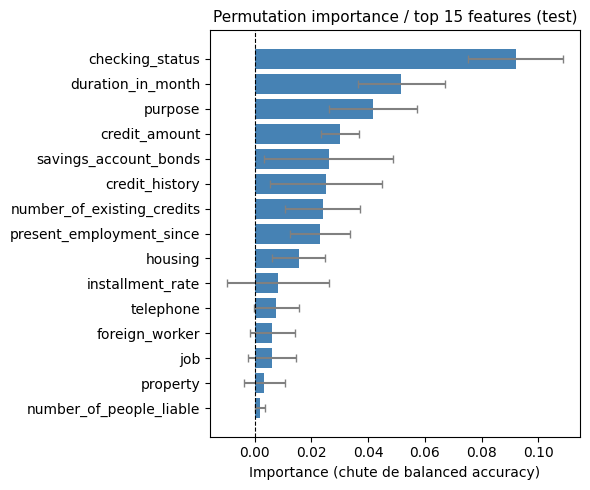

In [152]:
top_n  = 15
plot_df = perm_importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(
    plot_df['feature'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std'],
    color='steelblue',
    ecolor='gray',
    capsize=3,
)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Importance (chute de balanced accuracy)', fontsize=10)
ax.set_title(f'Permutation importance / top {top_n} features (test)', fontsize=11)
plt.tight_layout()
plt.show()

Une importance élevée signifie que mélanger cette variable dégrade nettement la balanced accuracy.  

-> Le modèle utilise fortement cette information pour ses décisions.

Une importance proche de 0 signifie que le modèle se comporte presque pareil lorsque cette variable est mélangée.

## 7.4 Contributions locales linéaires

Les coefficients globaux expliquent le comportement général du modèle
.  
Ici, on veut expliquer une décision précise pour un seul exemple du test.

Comme le modèle est linéaire, le logit se décompose exactement :

`logit = b + Σ w_i × x_i`

La contribution locale de chaque feature est donc `w_i × x_i`.

Exemple 0 logit : -4.487  |  score P(y_bad=1) : 0.011
Vraie classe : y_bad = 0  |  Décision : approve = 1



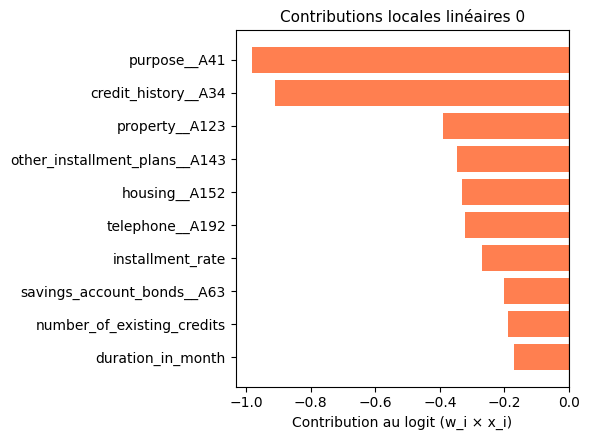

,feature,value,contribution
0,purpose__A41,1.000,-0.983
1,credit_history__A34,1.000,-0.912
2,property__A123,1.000,-0.391
3,other_installment_plans__A143,1.000,-0.346
4,housing__A152,1.000,-0.332
5,telephone__A192,1.000,-0.322
6,installment_rate,-0.841,-0.269
7,savings_account_bonds__A63,1.000,-0.203
8,number_of_existing_credits,-0.711,-0.189
9,duration_in_month,-0.460,-0.170


In [155]:
idx_example = 0
x_ex  = X_test[idx_example]
logit = float(x_ex @ w_base + b_base)
score = float(sigmoid(logit))

contrib_df = pd.DataFrame({
    'feature'         : prep.feature_names_,
    'value'           : x_ex,
    'contribution'    : w_base * x_ex,
    'abs_contribution': np.abs(w_base * x_ex),
}).sort_values('abs_contribution', ascending=False).head(10).reset_index(drop=True)

print(f"Exemple {idx_example} logit : {logit:.3f}  |  score P(y_bad=1) : {score:.3f}")
print(f"Vraie classe : y_bad = {y_test[idx_example]}  |  Décision : approve = {1 - int(score >= thr_base)}")
print()


plot_c = contrib_df.iloc[::-1]
colors = ['steelblue' if c > 0 else 'coral' for c in plot_c['contribution']]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(plot_c['feature'], plot_c['contribution'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Contribution au logit (w_i × x_i)', fontsize=10)
ax.set_title(f'Contributions locales linéaires {idx_example}', fontsize=11)
plt.tight_layout()
plt.show()

display(contrib_df[['feature', 'value', 'contribution']].round(3))

Les barres bleues augmentent le logit, donc elles poussent le score vers "mauvais crédit". 

Les barres oranges diminuent le logit, donc elles poussent le score vers "bon crédit".

La somme de toutes les contributions + le biais `b` redonne exactement le logit affiché.  

# 8. Robustesse

## 8.1 Fonction de perturbation

Pour tester la robustesse du modèle, on ajoute un bruit artificiel sur les variables numériques du test.

Les variables numériques ont été standardisées avec un z-score.  
Un bruit gaussien `N(0, σ²)` avec `σ = 0.2` correspond donc à une perturbation modérée : environ 20 % d'un écart-type.

Attention : on ne perturbe pas les colonnes one-hot, car elles représentent des catégories ( ajouter un bruit continu sur ces colonnes n'aurait pas vraiment de sens)

Comme le Preprocessor place les colonnes numériques en premier, les `n_num` premières colonnes de `X` correspondent aux variables numériques.

In [157]:
n_num = len(prep.num_cols_)

def perturb_numeric_features(X, sigma, seed=SEED):
    rng_pert = np.random.default_rng(seed)
    X_pert = X.copy()
    X_pert[:, :n_num] += rng_pert.normal(0, sigma, size=(len(X), n_num))
    return X_pert

# Test
X_test_pert = perturb_numeric_features(X_test, sigma=0.2)

diff_num = np.abs(X_test_pert[:, :n_num] - X_test[:, :n_num]).mean()
diff_ohe = np.abs(X_test_pert[:, n_num:] - X_test[:, n_num:]).mean()

print(f"Différence moyenne sur colonnes numériques : {diff_num:.4f}")
print(f"Différence moyenne sur colonnes one-hot    : {diff_ohe:.4f}")

Différence moyenne sur colonnes numériques : 0.1556
Différence moyenne sur colonnes one-hot    : 0.0000


## 8.2 Évaluation perturbée à sigma = 0.2

On commence avec une perturbation modérée : `sigma = 0.2`.

Avec cette perturbation, notre objectif n'est pas de simuler une attaque extrême mais plutot de vérifier si le modèle reste stable lorsque les mesures numériques sont dégradées. 

On garde exactement le même modèle et le même seuil `thr_base` (seules les entrées du test sont modifiées)

In [158]:
scores_test_pert  = sigmoid(X_test_pert @ w_base + b_base)
risk_pred_test_pert = predict_from_scores(scores_test_pert, thr_base)
approve_test_pert   = approve_from_pred(risk_pred_test_pert)

metrics_pert                        = evaluate_predictions(y_test, scores_test_pert, thr_base)
fair_pert_by_group, fair_pert_summary = fairness_audit(y_test, approve_test_pert, s_test)

def _rob_row(name, metrics, approval_rate, fairness):
    return {
        'configuration'    : name,
        'roc_auc'          : round(metrics['roc_auc'],           3),
        'balanced_accuracy': round(metrics['balanced_accuracy'], 3),
        'business_cost'    : metrics['business_cost'],
        'approval_rate'    : round(float(approval_rate),         3),
        'dp_diff'          : round(fairness['dp_diff'],          3),
        'eo_diff'          : round(fairness['eo_diff'],          3),
        'eodds_gap'        : round(fairness['eodds_gap'],        3),
    }

rob_comparison = pd.DataFrame([
    _rob_row('Baseline (sigma=0)',   metrics_base,  approve_test.mean(),      fair_base_summary),
    _rob_row('Baseline (sigma=0.2)', metrics_pert,  approve_test_pert.mean(), fair_pert_summary),
]).set_index('configuration')

display(rob_comparison)

,roc_auc,balanced_accuracy,business_cost,approval_rate,dp_diff,eo_diff,eodds_gap
configuration,,,,,,,
Baseline (sigma=0),0.789,0.719,100,0.44,0.123,0.115,0.115
Baseline (sigma=0.2),0.787,0.719,100,0.44,0.123,0.115,0.115


Ce tableau compare le modèle sur les données originales et sur les données perturbées avec `sigma = 0.2`.

- Si les métriques changent peu : le modèle est assez stable face a ce niveau de bruit cela indique que le modèle est assez stable face à ce niveau de bruit
- Si elles changent beaucoup : le modèle dépend fortement de valeurs numériques précises

On observe aussi les métriques de fairnesscar une perturbation peut modifier les écarts entre groupes même si la performance globale reste proche.

## 8.3 Courbe de dégradation selon 

Après le test avec `sigma = 0.2`, on étudie plusieurs niveaux de bruit.

Comme les variables numériques sont standardisées, les valeurs de `sigma` sont faciles à interpréter :
- `sigma = 0` : aucune perturbation 
- `sigma = 0.1` : bruit faible 
- `sigma = 0.5` : bruit plus important (environ la moitié d’un écart-type)

L’objectif est de voir si les performances se dégradent progressivement quand les entrées deviennent moins fiables.  

,sigma,roc_auc,balanced_accuracy,business_cost,dp_diff,eo_diff,eodds_gap
0,0.0,0.789,0.719,100,0.123,0.115,0.115
1,0.1,0.789,0.715,101,0.118,0.107,0.107
2,0.2,0.788,0.708,103,0.149,0.157,0.157
3,0.3,0.789,0.695,112,0.080,0.099,0.099
4,0.4,0.794,0.705,104,0.143,0.149,0.149
5,0.5,0.786,0.688,114,0.026,0.082,0.160


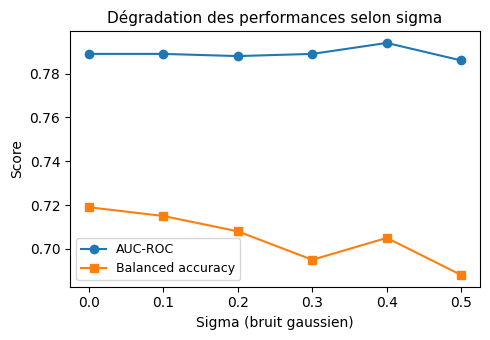

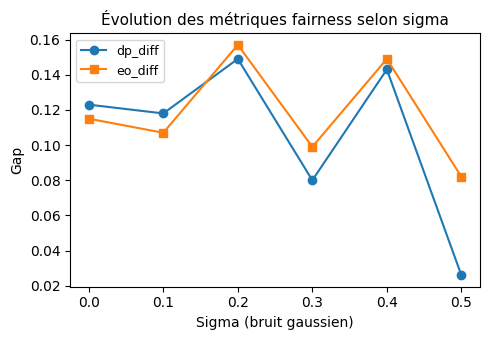

In [159]:
sigma_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
rob_rows = []

for i, sigma in enumerate(sigma_values):
    X_pert = perturb_numeric_features(X_test, sigma=sigma, seed=SEED + i)
    scores_pert  = sigmoid(X_pert @ w_base + b_base)
    risk_pert    = predict_from_scores(scores_pert, thr_base)
    approve_pert = approve_from_pred(risk_pert)

    m  = evaluate_predictions(y_test, scores_pert, thr_base)
    _, fs = fairness_audit(y_test, approve_pert, s_test)

    rob_rows.append({
        'sigma'            : sigma,
        'roc_auc'          : round(m['roc_auc'],           3),
        'balanced_accuracy': round(m['balanced_accuracy'], 3),
        'business_cost'    : m['business_cost'],
        'dp_diff'          : round(fs['dp_diff'],          3),
        'eo_diff'          : round(fs['eo_diff'],          3),
        'eodds_gap'        : round(fs['eodds_gap'],        3),
    })

robustness_curve = pd.DataFrame(rob_rows)
display(robustness_curve.round(3))

# Fig 1 : performance
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(robustness_curve['sigma'], robustness_curve['roc_auc'],
        marker='o', label='AUC-ROC')
ax.plot(robustness_curve['sigma'], robustness_curve['balanced_accuracy'],
        marker='s', label='Balanced accuracy')
ax.set_xlabel('Sigma (bruit gaussien)', fontsize=10)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Dégradation des performances selon sigma', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Fig 2 : fariness
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(robustness_curve['sigma'], robustness_curve['dp_diff'],
        marker='o', label='dp_diff')
ax.plot(robustness_curve['sigma'], robustness_curve['eo_diff'],
        marker='s', label='eo_diff')
ax.set_xlabel('Sigma (bruit gaussien)', fontsize=10)
ax.set_ylabel('Gap', fontsize=10)
ax.set_title('Évolution des métriques fairness selon sigma', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Ici, le bruit gaussien simule une dégradation des variables numériques, par exemple une imprécision de mesure ou une donnée numérique moins fiable.

- Si l’AUC et la balanced accuracy restent proches quand `sigma` augmente -> le modèle est plutôt stable.
- Si elles diminuent fortement -> le modèle dépend beaucoup des valeurs exactes des variables numériques.

Donc dans notre cas les performances restent globalement assez stables, mais le coût métier et certains écarts de fairness varient selon le niveau de bruit.  

La robustesse ne se résume donc pas seulement a l'AUC.

# 9. Analyse des compromis

## 9.1 Tableau final des compromis

On rassemble maintenant les principaux résultats dans un même tableau.

L'objectif est de comparer plusieurs critères en même temps :
- performance globale 
- coût métier 
- taux d'approbation 
- métriques de fairness 
- stabilité sous perturbation

On compare baseline / modèle avec reweighing / deux versions du baseline avec bruit sur les variables numériques.

On inclut aussi `sigma = 0.5` comme scénario de bruit plus fort, pour voir si les conclusions restent stables quand les données numériques sont davantage perturbées.

In [160]:
# Cas sigma = 0.5
X_pert_05  = perturb_numeric_features(X_test, sigma=0.5, seed=SEED + 5)
scores_05  = sigmoid(X_pert_05 @ w_base + b_base)
approve_05 = approve_from_pred(predict_from_scores(scores_05, thr_base))
metrics_05 = evaluate_predictions(y_test, scores_05, thr_base)
_, fair_05 = fairness_audit(y_test, approve_05, s_test)


def _final_row(name, metrics, approval_rate, fairness):
    return {
        'configuration'   : name,
        'roc_auc'         : round(metrics['roc_auc'],           3),
        'balanced_acc.'   : round(metrics['balanced_accuracy'], 3),
        'business_cost'   : metrics['business_cost'],
        'approval_rate'   : round(float(approval_rate),         3),
        'dp_diff'         : round(fairness['dp_diff'],          3),
        'disp_impact'     : round(fairness['disparate_impact'], 3),
        'eo_diff'         : round(fairness['eo_diff'],          3),
        'eodds_gap'       : round(fairness['eodds_gap'],        3),
    }


final_table = pd.DataFrame([
    _final_row('Baseline',               metrics_base,       approve_test.mean(),      fair_base_summary),
    _final_row('Reweighing',             fair_model_metrics, approve_fair_test.mean(), fair_model_summary),
    _final_row('Baseline + noise σ=0.2', metrics_pert,       approve_test_pert.mean(), fair_pert_summary),
    _final_row('Baseline + noise σ=0.5', metrics_05,         approve_05.mean(),        fair_05),
]).set_index('configuration')

display(final_table)

,roc_auc,balanced_acc.,business_cost,approval_rate,dp_diff,disp_impact,eo_diff,eodds_gap
configuration,,,,,,,,
Baseline,0.789,0.719,100,0.440,0.123,0.730,0.115,0.115
Reweighing,0.789,0.715,101,0.435,0.118,0.739,0.107,0.107
Baseline + noise σ=0.2,0.787,0.719,100,0.440,0.123,0.730,0.115,0.115
Baseline + noise σ=0.5,0.786,0.688,114,0.430,0.026,0.940,0.082,0.160


Ce tableau montre qu'il n'existe pas de configuration meilleure sur tous les critères.

Le baseline garde de bonnes performances globales, avec une AUC et une balanced accuracy correctes. 

Cependant, il présente aussi des écarts entre groupes d'âge visibles dans `dp_diff`, `disparate_impact` et `eo_diff`.

Le reweighing modifie légèrement ces écarts, mais l'amélioration reste limitée dans ce test.  

Les versions perturbées montrent que les résultats peuvent changer quand les variables numériques deviennent moins fiables.  

Le choix final dépend donc de la priorité : performance, coût métier, équité ou robustesse.

# 10. Limites et IA responsable

## 10.1 Limites du dataset

Le German Credit dataset est assez petit : il contient seulement 1 000 exemples.  
Les variables sont aussi anciennes et codées avec des catégories simplifiées comme `A11`, `A12`, etc.

Les résultats que nous avons obtenus dans ce notebook ne peuvent donc pas être généralisés directement à un vrai système bancaire moderne.  

L'attribut sensible choisi est l'âge, avec le seuil young < 25 ans.  
C'est disctuable car un autre découpage pourrait donner des résultats différents.

## 10.2 Limites des métriques de fairness

Dans ce projet, on mesure surtout de la **group fairness** : on compare les décisions du modèle entre deux groupes d'âge.

Ces métriques sont utiles mais elles ne racontent pas tout.

-> Par exemple, améliorer `dp_diff` ne garantit pas forcément d'améliorer `eo_diff` ou le coût métier.

Il faut donc éviter de conclure qu'un modèle est équitable à partir d'une seule métrique.  

## 10.3 Limites du modèle

Nous avons utilisé une régression logistique simple, un choix évident car le modèle est facile à comprendre et à interpréter.

Les coefficients globaux et les contributions locales sont lisibles, ce qui est utile pour un audit.  

En revanche, un modèle plus complexe pourrait peut-être obtenir de meilleures performances.

Attention : les coefficients ne sont pas causaux, ils montrent seulement les associations apprises par le modèle sur les données d'entrainement.

## 10.4 Limites de la robustesse

Pour le test de robustesse nous sommes restés sur quelque chose de simple :  
On ajoute seulement du bruit gaussien sur les variables numériques standardisées.

-> Les variables catégorielles encodées en one-hot ne sont pas perturbées. 

Dans un vrai cas d'usage, il pourrait aussi y avoir des erreurs de saisie / des catégories manquantes / des changements dans la distribution des données.

## 10.5 Utilisation de l'IA générative

Nous avons utilisé Claude comme aide ponctuelle pendant le projet.

Il nous a surtout servi à proposer un plan de travail général pour organiser le notebook, et a aussi été utilisé pour demander de l'aide sur une partie de code plus compliqué : la permutation importance avec regroupement des colonnes one-hot par variable catégorielle.

Le reste du notebook a été construit et vérifié manuellement (codes, choix méthodologiques, conclusions etc.)

## 10.6 Conclusion

- Le modèle baseline donne des performances correctes sur ce dataset, avec une AUC et une balanced accuracy raisonnables.

- Le reweighing permet de tester une première méthode de mitigation de biais : 
dans nos résultats, les gains restent limités mais cela permet de montrer le compromis entre performance, coût métier et fairness.

- L'interprétabilité aide à comprendre le comportement du modèle :  
Les coefficients, la permutation importance et les contributions locales donnent plusieurs points de vue complémentaires.

- Les tests de robustesse montrent aussi que les performances et les métriques de fairness peuvent changer lorsque les variables numériques sont perturbées.

Au final, ce projet montre qu'un modèle de scoring crédit ne doit pas être évalué uniquement avec l'accuracy, il faut aussi prendre en compte le coût des erreurs, les écarts entre groupes, l'interprétabilité et la robustesse des décisions.